#### imports and setup

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
import functions


importlib.reload(functions)

from functions import *
import torch 
import torch.nn as nn
import torch.nn.functional  as F

from torch import Tensor
from torchvision import transforms

import pandas as pd
import PIL.Image as Image

import kagglehub

/Users/nr1/Documents/DTU 4. Semester/Fagprojekt/Fagprojekt---Group-Equivariance/fag_projekt/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
path = kagglehub.dataset_download("zalando-research/fashionmnist")

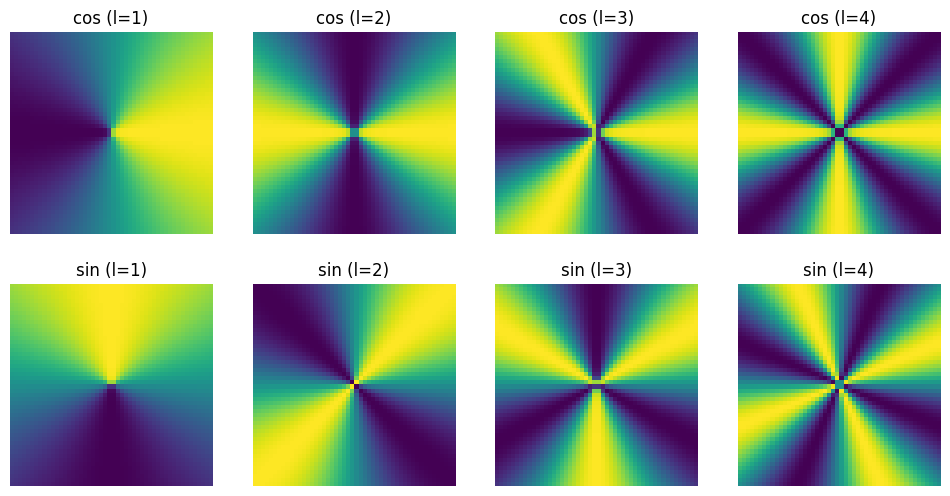

In [31]:
n = 50
basis, radius_map = functions.fourier_basis(n,4,plot = True)

## Classes

In [5]:
class MLP_Radius(nn.Module):
    def __init__(self, in_features= 1, hidden_units = 16, out_features = 1, bias = False, depth = 1):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.hidden_units = hidden_units
        self.depth = depth
        if bias:
            self.bias = nn.Parameter(torch.randn(out_features))
        else:
            self.bias = None
        
        layers = []
        layers += [nn.Linear(in_features, hidden_units, bias=bias), nn.ReLU()]
        for _ in range(depth-1):
            layers += [nn.Linear(hidden_units, hidden_units, bias=bias), nn.ReLU()]
        layers += [nn.Linear(hidden_units, out_features, bias=bias)]
        
        self.layer = nn.Sequential(*layers)               
        
    def forward(self, x):
        return self.layer(x)


In [ ]:
class LiftingLayer(nn.Module):
    def __init__(self, in_features, out_features, kernel_size, l,  bias=True):
        super(LiftingLayer, self).__init__()
        self.MLP_Radius_ = MLP_Radius(bias = bias)
        # Define learnable parameters
        self.k_size = kernel_size
 
        self.l = l
        self.out_features = out_features
        
    def forward(self, x):
        # x shape: (batch_size, in_features)
        #fourier folder
        basis, radius_map = fourier_basis(kernel_size = self.k_size, l = self.l)
        radius_map = torch.tensor(radius_map).float().flatten().unsqueeze(1)
        kernels = []
        for _ in range(self.out_features):
            for i in range(len(basis)):
                radial_weights = self.MLP_Radius_(radius_map).squeeze_().reshape(self.k_size,self.k_size)
                kernels.append(basis[i] * radial_weights)
        kernels = torch.stack(kernels).unsqueeze_(1)

        out = F.conv2d(input = x, weight=kernels) #??? SKAL vi specificerer bias, stride padding???
        
        return out
    
    

ll = LiftingLayer(in_features=10,out_features= 10,kernel_size= 5,l =3)

# MNIST


In [70]:
#Laver vores MNIST image
RESIZE_SIZE = 28

df = pd.read_csv(path + '/fashion-mnist_train.csv')
row1 = df.iloc[0, 1:].values
pixel = row1.reshape(28,28).astype(np.uint8)

img = Image.fromarray(pixel)
print(img.resize((RESIZE_SIZE, RESIZE_SIZE), Image.NEAREST))

transform = transforms.ToTensor()

img = img.resize((RESIZE_SIZE, RESIZE_SIZE), Image.NEAREST)

image = transform(img)


image = image.unsqueeze_(0).to(torch.complex128)

<PIL.Image.Image image mode=L size=28x28 at 0x177BF8470>


In [77]:
num_images = 1000
df_train = df[:num_images]

# Split labels og pixels
labels = df_train.iloc[:, 0].values            # første kolonne = label
pixels = df_train.iloc[:, 1:].values           # resten = 784 pixels per række

# Til tensor + reshape til (N, C, H, W)
images = torch.tensor(pixels, dtype=torch.float32) / 255.0   # normaliser [0,1]
images = images.reshape(-1, 1, 28, 28)         # (1000, 1, 28, 28)

labels = torch.tensor(labels, dtype=torch.long)

print(images.shape)  # torch.Size([1000, 1, 28, 28])
print(labels.shape)  # torch.Size([1000])

torch.Size([1000, 1, 28, 28])
torch.Size([1000])


<class 'numpy.ndarray'>


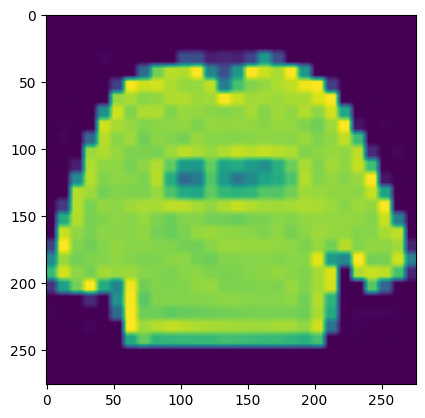

In [66]:
image.shape

out = ll.forward(image)

out[0][7].shape

putput = out[0][4].detach().numpy()
amps = np.abs(putput)
print(type(putput))
plt.imshow(amps)

## Convolutions

In [67]:
if False:
    x = (np.linspace(-2.5 *np.pi ,2.5*np.pi,100))
    x = np.random.permutation(x)

    x = torch.tensor(x).float().unsqueeze_(1)
    print(x.shape)
    y = np.sin(x)
    y = torch.tensor(y)
    model = MLP_Radius(bias = True, hidden_units=100, depth = 2)
    MLP_Radius
    criterion = nn.MSELoss()

    # optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    # training loop
    epochs = 50000


    for epoch in range(epochs):
        optimizer.zero_grad()

        # forward pass
        outputs = model(x)

        # compute loss
        loss = criterion(outputs, y)

        # backward pass
        loss.backward()

        # update weights
        optimizer.step()
        
        # if epoch % 10 == 0:
        #     print(f"epoch {epoch}, loss = {loss.item():.4f}")
    output = model.forward(x)

    output = torch.detach(output)
    plt.scatter(x, output.numpy())
    plt.scatter(x , y.numpy())

# Train!

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

model = LiftingLayer(in_features=1,out_features= 10,kernel_size= 5,l =3)


criterion = nn.MSELoss()

# optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
# training loop
epochs = 5


for epoch in range(epochs):
    optimizer.zero_grad()

    #insæt batch??
    
    # forward pass
    outputs = model(images)

    # compute loss
    loss = criterion(outputs, labels)

    # backward pass
    loss.backward()

    # update weights
    optimizer.step()
    
    # if epoch % 10 == 0:
    #     print(f"epoch {epoch}, loss = {loss.item():.4f}")
output = model.forward(x)

RuntimeError: Mismatched Tensor types in NNPack convolutionOutput

## Ækvivarians-test

Tester om laget er ækvivariant: $\Phi(R \cdot x) \stackrel{?}{=} R \cdot \Phi(x)$.

**Bemærk:** Ækvivarians er en strukturel egenskab af arkitekturen — den er der eller den er der ikke. Ingen træning nødvendig.

Den øverste række (rotér input → Φ) skal ligne den nederste række (Φ → rotér output). Numerisk fejl skal være tæt på 0 for vinkler der er multipler af 90° (ingen interpolations-støj). Ved 45°/135° er der altid en lille fejl pga. bilinær rotation.

Vi viser **magnitude** (`|·|`) af output for at undgå at skulle vælge real- eller imag-del separat for komplekse outputs.

Layer accepterer dtype: torch.complex128
Angle=  0°  equivariance error = 0.000000
Angle= 45°  equivariance error = 0.461057
Angle= 90°  equivariance error = 0.536884
Angle=135°  equivariance error = 0.588699
Angle=180°  equivariance error = 0.506556


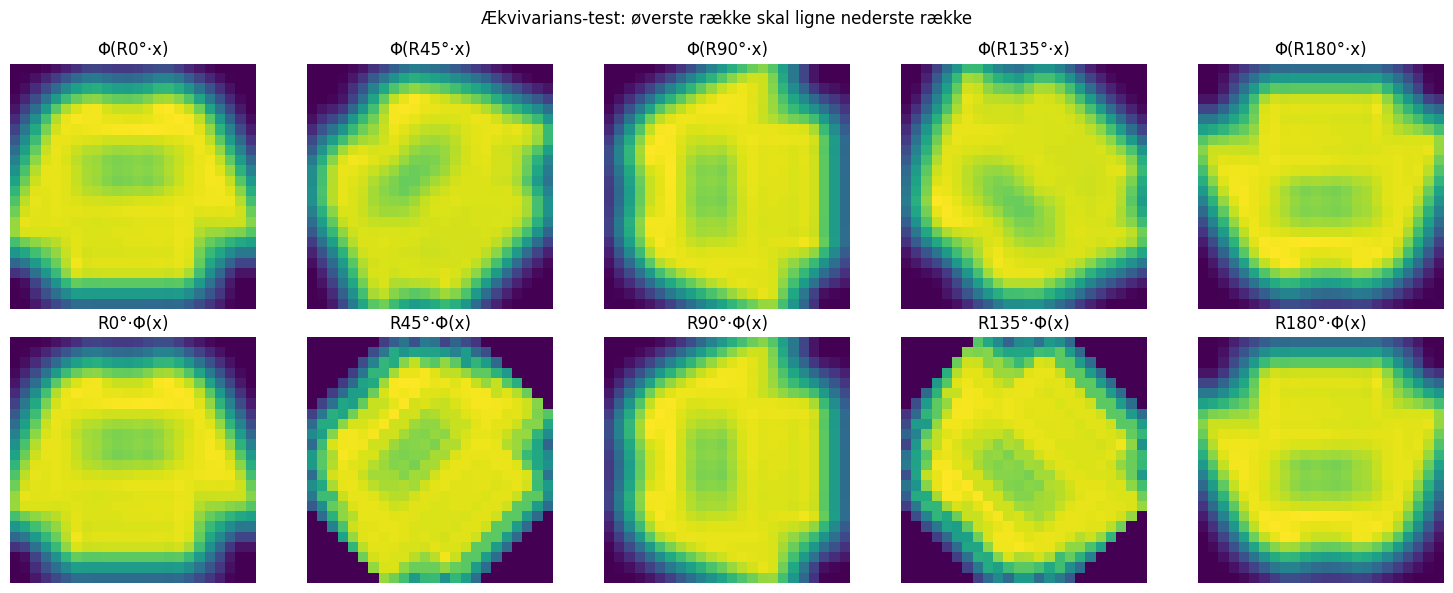

In [80]:
import torchvision.transforms.functional as TF

# --- Helper: TF.rotate kan ikke håndtere complex tensors direkte;
#     vi roterer real og imag separat hvis input er complex ---
def rotate_any(x, angle):
    if x.is_complex():
        return torch.complex(TF.rotate(x.real, angle), TF.rotate(x.imag, angle))
    return TF.rotate(x, angle)

# --- Helper: detekter hvilken dtype LiftingLayer faktisk accepterer ---
def detect_layer_dtype(layer, sample):
    for dt in (torch.complex128, torch.complex64, torch.float32):
        try:
            with torch.no_grad():
                _ = layer(sample.to(dt))
            return dt
        except Exception:
            continue
    raise RuntimeError('Ingen af de afprøvede dtypes virker for dette lag')

INPUT_DTYPE = detect_layer_dtype(ll, images[0:1])
print(f'Layer accepterer dtype: {INPUT_DTYPE}')

# --- Vælg test-billede med korrekt dtype ---
test_image = images[0:1].to(INPUT_DTYPE)

# --- Vinkler at teste ---
angles = [0, 45, 90, 135, 180]

ll.eval()
with torch.no_grad():
    # Beregn Φ(x) én gang udenfor løkken
    out_unrot = ll(test_image)

    fig, axes = plt.subplots(2, len(angles), figsize=(3*len(angles), 6))

    for k, angle in enumerate(angles):
        # Vej 1: rotér INPUT først, så Φ
        rotated_input = rotate_any(test_image, angle).to(INPUT_DTYPE)
        out_rot_then_phi = ll(rotated_input)

        # Vej 2: Φ først, så rotér OUTPUT
        out_phi_then_rot = rotate_any(out_unrot, angle)

        # Numerisk forskel — på magnitude (virker for både real og complex)
        err = (out_rot_then_phi - out_phi_then_rot).abs().mean().item()
        print(f'Angle={angle:3d}°  equivariance error = {err:.6f}')

        # Plot magnitude af kanal 0
        img1 = out_rot_then_phi[0, 0].abs().detach().numpy()
        img2 = out_phi_then_rot[0, 0].abs().detach().numpy()

        axes[0, k].imshow(img1)
        axes[0, k].set_title(f'Φ(R{angle}°·x)')
        axes[0, k].axis('off')

        axes[1, k].imshow(img2)
        axes[1, k].set_title(f'R{angle}°·Φ(x)')
        axes[1, k].axis('off')

    plt.suptitle('Ækvivarians-test: øverste række skal ligne nederste række')
    plt.tight_layout()
    plt.show()